In [12]:
import numpy as np
import pandas as pd

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent))
from src.features.build_features import load_data,get_skewed_features, inspect_target_co2_relation,add_time_features,add_power_features, apply_logtransform, save_processed_data 

sys.path.append('..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Load Clean Data

In [13]:
df = load_data()
df.head(3)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   Usage_kWh                             35040 non-null  float64       
 1   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64       
 2   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 3   CO2(tCO2)                             35040 non-null  float64       
 4   Lagging_Current_Power_Factor          35040 non-null  float64       
 5   Leading_Current_Power_Factor          35040 non-null  float64       
 6   NSM                                   35040 non-null  int64         
 7   WeekStatus                            35040 non-null  str           
 8   Day_of_week                           35040 non-null  str           
 9   Load_Type                             35040 non-null  str           
 10  consumed_

# 2. Feature Engineering

According to the feature analysis in EDA notebook, I here carry out features engineering.


## 2.1 Checking Data Leakage - relationship between `CO2(tCO2)` and target
I investigated whether CO2 is directly calculated from usage or independtly measured.

In [14]:
target = 'Usage_kWh'
co2_target_ratio = inspect_target_co2_relation(df,'CO2(tCO2)',target)

correlation value =0.9882, unique values in CO2(tCO2)=8


The correlation value between target and `CO2` is very high, and it has tiny uniqueness : only 8 unique value against 3343 unique `Usage_kwh`. Therefore, I planned to remove it.

In [15]:
df = df.drop(['CO2(tCO2)'], axis = 1)
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00


## 2.2 Log Transformation to Right-Skewed Features

As I mentioned in EDA, right-skewed features are needed to apply log transformation.
The `Yeo-Johnson` step for left-skewed features is intentionally pushed to a later train/test-split stage in modeling notebook.

In [16]:
col_num = df.select_dtypes(include=['float64','int64']).columns.tolist()
col_num = [c for c in col_num if c != target]

left_skew_feat, right_skew_feat = get_skewed_features(df,col_num)
df = apply_logtransform(df, right_skew_feat)
df.head(3)

Left skewed features: []
Right skewed features: ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor']


,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,Lagging_Current_Reactive.Power_kVarh_logged,Leading_Current_Reactive_Power_kVarh_logged,Lagging_Current_Power_Factor_logged,Leading_Current_Power_Factor_logged
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,1.373716,0.0,4.306899,4.615121
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,1.697449,0.0,4.216120,4.615121
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,1.453953,0.0,4.266616,4.615121


## 2.3 Adding time related features
- `nsm_sin`
- `nsm_cos`
- `is_weekend`
- `nsm_sin_loadtype`
- `nsm_cos_loadtype`

As features `NSM` show shift data structure, it interaction with operation regime (shift, week status, load type); whether production shift at week days consume more electrical usage or weekend shift used more with respect to load type.


In [17]:
df = add_time_features(df)
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,Lagging_Current_Reactive.Power_kVarh_logged,Leading_Current_Reactive_Power_kVarh_logged,Lagging_Current_Power_Factor_logged,Leading_Current_Power_Factor_logged,nsm_sin,nsm_cos,is_weekend,nsm_sin_loadtype,nsm_cos_loadtype
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,1.373716,0.0,4.306899,4.615121,0.065403,0.997859,0,0.065403,0.997859
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,1.697449,0.0,4.216120,4.615121,0.130526,0.991445,0,0.130526,0.991445
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,1.453953,0.0,4.266616,4.615121,0.195090,0.980785,0,0.195090,0.980785


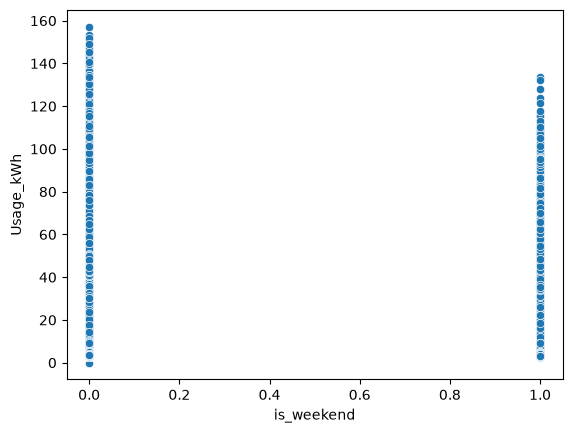

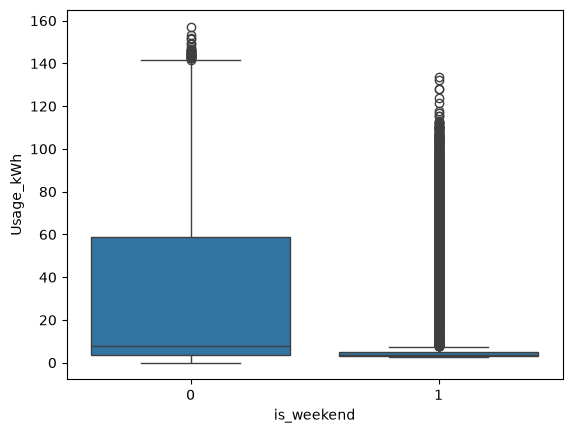

In [18]:
sns.scatterplot(data=df, x='is_weekend', y=target)
plt.show()

sns.boxplot(data=df, x='is_weekend', y=target)
plt.show()

## 2.4 Adding power related features 
- `total_reactive`
- `reactive_mode`
- `pf_loss`
- `electrical_load`
- `near_unity_pf`


In [19]:
unity_threshold = 95
df = add_power_features(df,unity_threshold)
df.head(3)

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,consumed_date,...,nsm_sin,nsm_cos,is_weekend,nsm_sin_loadtype,nsm_cos_loadtype,total_reactive,reactive_mode,pf_loss,electrical_load,near_unity_pf
0,3.17,2.95,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,2018-01-01 00:15:00,...,0.065403,0.997859,0,0.065403,0.997859,2.95,lagging_dominant,26.79,79.0305,1
1,4.00,4.46,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,2018-01-01 00:30:00,...,0.130526,0.991445,0,0.130526,0.991445,4.46,lagging_dominant,33.23,148.2058,1
2,3.24,3.28,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,2018-01-01 00:45:00,...,0.195090,0.980785,0,0.195090,0.980785,3.28,lagging_dominant,29.72,97.4816,1


# 3. Feature engineering summary

I concluded that the following eight newly engineered features would enhance the model's performance.

- `nsm_sin`, `nsm_cos`  
Preserve cyclical nature of time

- `is_weekend`  
Different factory operation schedules

- `nsm_sin_loadtype`, `nsm_cos_loadtype`  
Capture interaction between time and load type

- `total_reactive`  
Total reactive power demand

- `reactive_mode`  
Dominant reactive power direction

- `pf_loss`  
Distance from ideal power factor

- `electrical_load`  
Approximate electrical loading

- `near_unity_pf`  
Indicator of efficient power factor

# 4. Saving processed data

After feature engineering is done, this preprocessed data is saved for modeling.

In [20]:
expected_new_cols = ['nsm_sin', 'nsm_cos', 'is_weekend', 'nsm_sin_loadtype', 'nsm_cos_loadtype', 'total_reactive', 'reactive_mode', 'pf_loss', 'electrical_load', 'near_unity_pf']
missing = [c for c in expected_new_cols if c not in df.columns]

assert not missing, f"Missing engineered features before save: {missing}"

save_processed_data(df)


Preprocessed Data is sucessfully saved.
